In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

data = pd.read_excel('/Users/dinuka/Projects/Crop_Prediction_Mahaweli_C_Zone/Dataset/Meteorological_Dataset_2015-2025.xlsx')
print('Shape:',data.shape); print('Period:',data['Date'].min().date(),'->',data['Date'].max().date())


Shape: (3378, 24)
Period: 2015-01-01 -> 2025-03-31


In [2]:
summary = data.describe()
print(summary)

                                Date  Dry_Morning  Wet_Morning  Dry_Evening  \
count                           3378  3365.000000  3365.000000  3365.000000   
mean   2020-04-19 01:47:51.047957504    28.005988    24.934776    31.178098   
min              2015-01-01 00:00:00    21.500000    19.500000    17.500000   
25%              2017-04-24 06:00:00    26.500000    24.200000    29.200000   
50%              2020-08-15 12:00:00    28.200000    25.000000    31.500000   
75%              2022-12-07 18:00:00    29.500000    25.500000    33.500000   
max              2025-03-31 00:00:00   229.000000   225.000000    38.400000   
std                              NaN     4.014015     3.628408     2.939365   

       Wet_Evening  Max. Temperature  Min. Temperarture  S. T. - 5cm Morning  \
count  3365.000000       3365.000000        3318.000000          3365.000000   
mean     25.360000         33.207088          22.636594            30.598220   
min       2.200000          0.600000           2

In [3]:
dd=pd.DataFrame([
 ('Date','date','—','Daily observation date (stored as Excel formulas =A2+1)','datetime'),
 ('Dry_Morning / Dry_Evening','dry_am / dry_pm','°C','Dry-bulb air temperature at morning / evening reading','numeric'),
 ('Wet_Morning / Wet_Evening','wet_am / wet_pm','°C','Wet-bulb temperature at morning / evening reading','numeric'),
 ('Max. Temperature','tmax','°C','Daily maximum air temperature','numeric'),
 ('Min. Temperarture','tmin','°C','Daily minimum air temperature (column name is misspelt)','numeric'),
 ('S. T. - 5/10/20/30cm Morning','st5_am … st30_am','°C','Soil temperature at depth, morning','numeric'),
 ('S. T. - 5/10/20/30cm Evening','st5_pm … st30_pm','°C','Soil temperature at depth, evening','numeric'),
 ('R. H. Morning / Evening','rh_am / rh_pm','%','Relative humidity','numeric'),
 ('Mean Velocity','wind_speed','km/h','Mean wind speed','numeric'),
 ('Wind Dirrection','wind_dir','compass','Prevailing wind direction (16-point + CALM / VRB)','categorical'),
 ('SunShine','sunshine','hours','Bright sunshine duration per day','numeric'),
 ('Rainefall','rain','mm','Daily rainfall','numeric'),
 ('Evaporation','evap','mm/day','TARGET: daily evaporation (contains "overflow" text entries)','numeric'),
],columns=['Original column','Clean name','Unit','Meaning','Type'])
dd

,Original column,Clean name,Unit,Meaning,Type
0,Date,date,—,Daily observation date (stored as Excel formul...,datetime
1,Dry_Morning / Dry_Evening,dry_am / dry_pm,°C,Dry-bulb air temperature at morning / evening ...,numeric
2,Wet_Morning / Wet_Evening,wet_am / wet_pm,°C,Wet-bulb temperature at morning / evening reading,numeric
3,Max. Temperature,tmax,°C,Daily maximum air temperature,numeric
4,Min. Temperarture,tmin,°C,Daily minimum air temperature (column name is ...,numeric
5,S. T. - 5/10/20/30cm Morning,st5_am … st30_am,°C,"Soil temperature at depth, morning",numeric
6,S. T. - 5/10/20/30cm Evening,st5_pm … st30_pm,°C,"Soil temperature at depth, evening",numeric
7,R. H. Morning / Evening,rh_am / rh_pm,%,Relative humidity,numeric
8,Mean Velocity,wind_speed,km/h,Mean wind speed,numeric
9,Wind Dirrection,wind_dir,compass,Prevailing wind direction (16-point + CALM / VRB),categorical


In [4]:
#Rename columns to clean names
RENAME={'Date':'date','Dry_Morning':'dry_am','Wet_Morning':'wet_am','Dry_Evening':'dry_pm','Wet_Evening':'wet_pm',
'Max. Temperature':'tmax','Min. Temperarture':'tmin','S. T. - 5cm Morning':'st5_am','S. T. - 10cm Morning':'st10_am',
'S. T. - 20cm Morning':'st20_am','S. T. - 30cm Morning':'st30_am','S. T. - 5cm Evening':'st5_pm','S. T. - 10cm Evening':'st10_pm',
'S. T. - 20cm Evening':'st20_pm','S. T. - 30cm Evening':'st30_pm','R. H. Morning':'rh_am','R. H. Evening':'rh_pm',
'Mean Velocity':'wind_speed','Wind Dirrection':'wind_dir','SunShine':'sunshine','Rainefall':'rain','Evaporation':'evap'}
r=data.rename(columns=RENAME)
print('Raw dtypes that are not numeric but should be:')
print(r.dtypes[r.dtypes==object].to_string())

Raw dtypes that are not numeric but should be:
wind_dir    object


In [6]:
#Gaps

df=pd.DataFrame({'date':r['date']})
full=pd.date_range(df.date.min(),df.date.max()); miss=full.difference(df.date)
print(f'Expected days {len(full)} | rows {len(df)} | missing calendar days {len(miss)} | duplicate dates {df.date.duplicated().sum()}')
print('Missing block:',miss.min().date(),'->',miss.max().date(),f'({len(miss)} consecutive days)')
print(df.groupby(df.date.dt.year).size().rename('rows per year').to_frame().T.to_string())

Expected days 3743 | rows 3378 | missing calendar days 365 | duplicate dates 0
Missing block: 2018-01-01 -> 2018-12-31 (365 consecutive days)
date           2015  2016  2017  2019  2020  2021  2022  2023  2024  2025
rows per year   365   366   365   365   366   365   365   365   366    90


In [10]:
#Missing values
print('Missing values per column:')
print(r.isnull().sum())

#Missing values per year
print()
print('Missing values per year:')
print(
    r.groupby(r['date'].dt.year)
     .apply(lambda x: x.isnull().sum().sum())
     .rename('missing values')
     .to_frame()
     .to_string()
)

Missing values per column:
date                           0
dry_am                        13
wet_am                        13
dry_pm                        13
wet_pm                        13
tmax                          13
tmin                          60
st5_am                        13
st10_am                        0
st20_am                        0
st30_am                      684
st5_pm                         0
st10_pm                        1
st20_pm                        0
st30_pm                      684
rh_am                          0
rh_pm                          0
wind_speed                     0
wind_dir                      10
sunshine                       2
rain                           9
evap                          61
Rainfall_Trace_Flag            0
Evaporation_Overflow_Flag      0
dtype: int64

Missing values per year:
      missing values
date                
2015             148
2016               8
2017               2
2019               8
2020            

In [12]:
# Suspicious but physically possible values: kept, flagged for review
print(r.loc[r.evap.nlargest(3).index,['date','evap','rain','sunshine']])

           date   evap  rain  sunshine
3286 2024-12-30  19.20  19.6       4.4
2385 2022-07-13   9.74   0.0       9.9
557  2016-07-11   9.68   0.0      10.8


Target variable summary statistics:
count    3317.000000
mean        4.010000
std         1.803635
min         0.020000
25%         2.710000
50%         3.920000
75%         5.210000
max        19.200000
Name: evap, dtype: float64


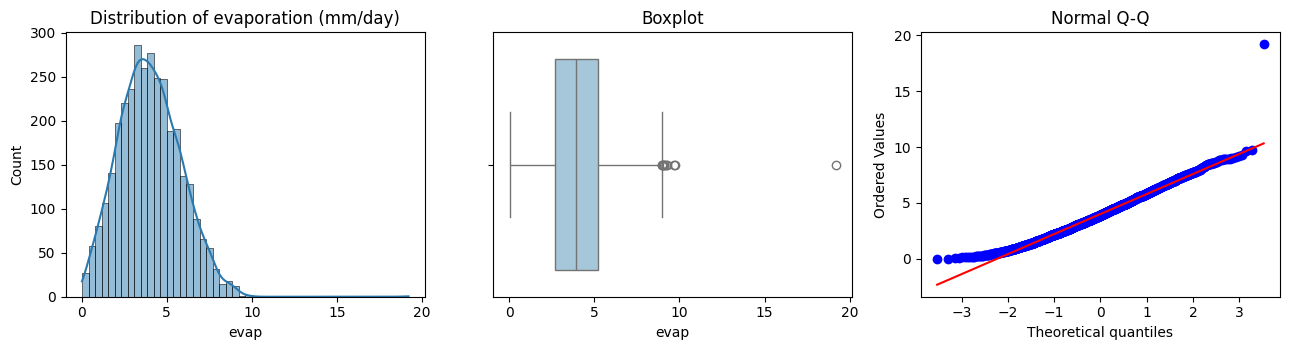

In [14]:
#Summary statistics for target variable
y = r.evap.dropna()
print('Target variable summary statistics:')
print(y.describe())

#Plots
fig,ax=plt.subplots(1,3,figsize=(13,3.6))
sns.histplot(y,bins=50,kde=True,ax=ax[0],color='#2a7ab0'); ax[0].set_title('Distribution of evaporation (mm/day)')
sns.boxplot(x=y,ax=ax[1],color='#9ecae1'); ax[1].set_title('Boxplot')
stats.probplot(y,dist='norm',plot=ax[2]); ax[2].set_title('Normal Q-Q'); plt.tight_layout(); plt.savefig('fig_target_dist.png',dpi=130)

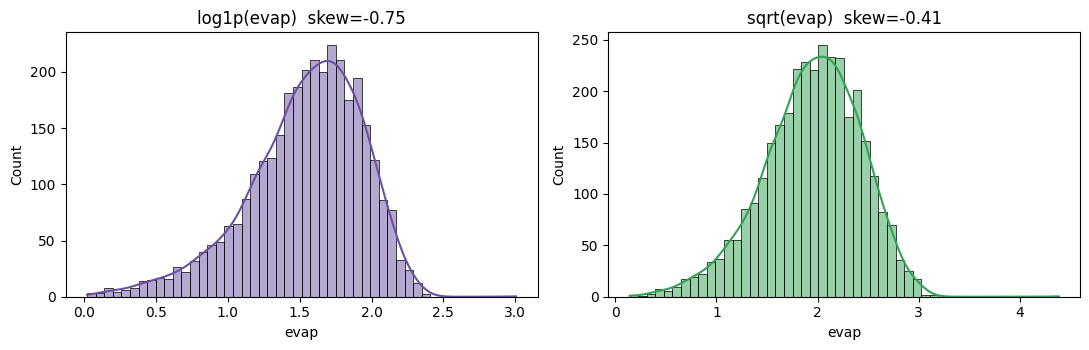

In [16]:
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
sns.histplot(np.log1p(y),bins=50,kde=True,ax=ax[0],color='#6a51a3'); ax[0].set_title(f'log1p(evap)  skew={np.log1p(y).skew():.2f}')
sns.histplot(np.sqrt(y),bins=50,kde=True,ax=ax[1],color='#31a354'); ax[1].set_title(f'sqrt(evap)  skew={np.sqrt(y).skew():.2f}')
plt.tight_layout(); plt.savefig('fig_target_transformed.png',dpi=130)

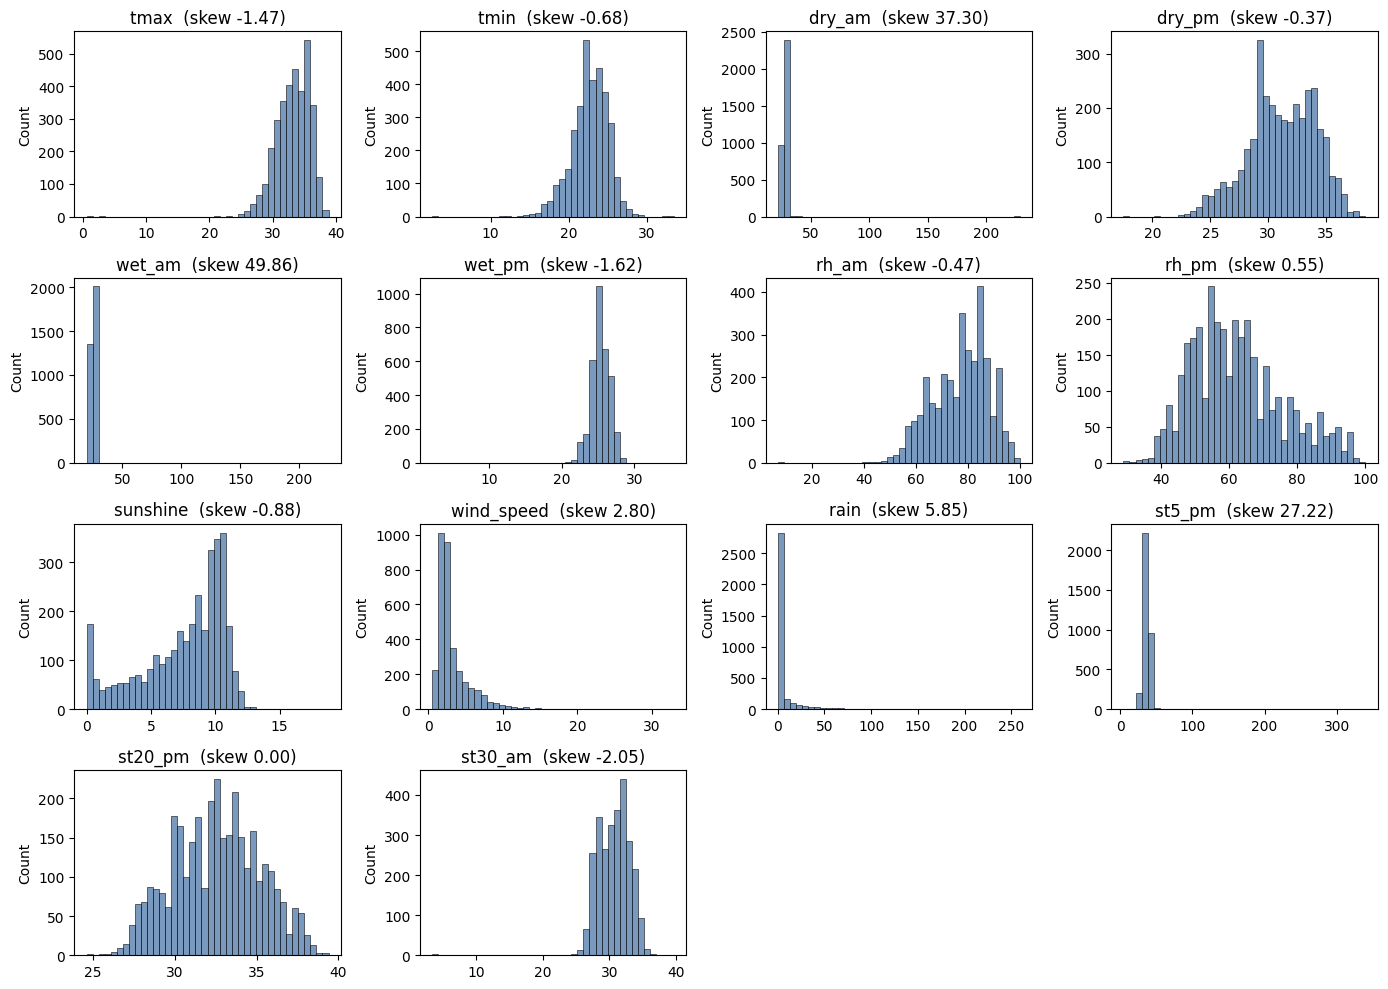

<Figure size 640x480 with 0 Axes>

In [17]:
#Feature distributions
feat=['tmax','tmin','dry_am','dry_pm','wet_am','wet_pm','rh_am','rh_pm','sunshine','wind_speed','rain','st5_pm','st20_pm','st30_am']
fig,axs=plt.subplots(4,4,figsize=(14,10)); axs=axs.ravel()
for a,c in zip(axs,feat):
    sns.histplot(r[c].dropna(),bins=40,ax=a,color='#4c78a8'); a.set_title(f'{c}  (skew {r[c].skew():.2f})'); a.set_xlabel('')
for a in axs[len(feat):]: a.axis('off')
plt.tight_layout(); plt.savefig('fig_feature_dist.png',dpi=130); plt.show(); plt.savefig('fig_feature_dist.png',dpi=130)

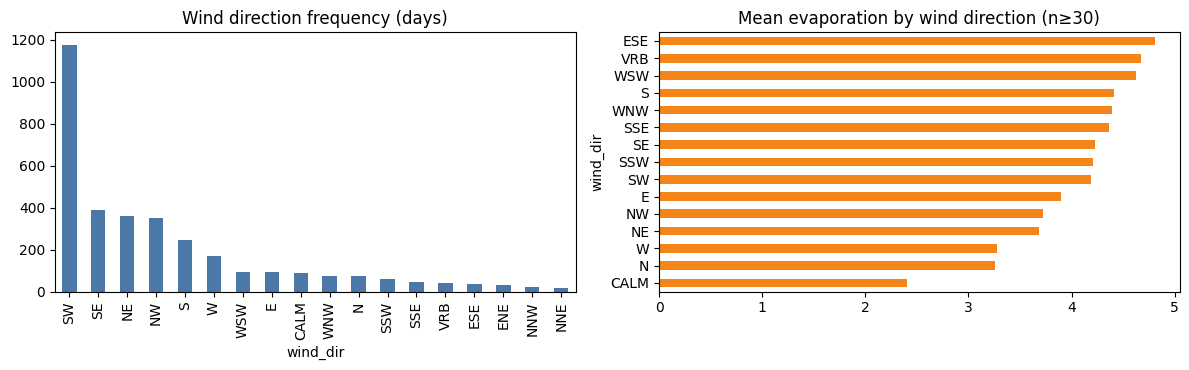

<Figure size 640x480 with 0 Axes>

In [18]:
wd=r.wind_dir.value_counts()
fig,ax=plt.subplots(1,2,figsize=(12,3.8))
wd.plot.bar(ax=ax[0],color='#4c78a8'); ax[0].set_title('Wind direction frequency (days)')
order=r.groupby('wind_dir').evap.agg(['mean','count']).query('count>=30').sort_values('mean')
order['mean'].plot.barh(ax=ax[1],color='#f58518'); ax[1].set_title('Mean evaporation by wind direction (n≥30)'); plt.tight_layout(); plt.show(); plt.savefig('fig_wind_dir.png',dpi=130)

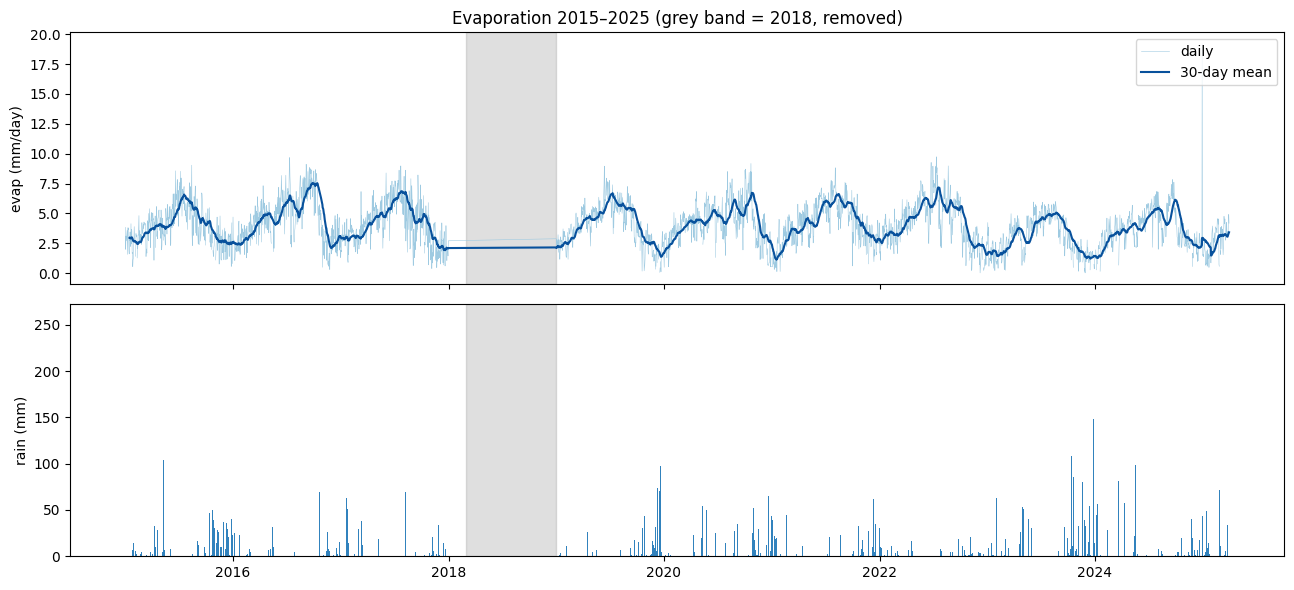

<Figure size 640x480 with 0 Axes>

In [25]:
#Temporal patterns
ts=r.set_index('date')
fig,ax=plt.subplots(2,1,figsize=(13,6),sharex=True)
ax[0].plot(ts.evap,lw=.4,color='#9ecae1',label='daily'); ax[0].plot(ts.evap.rolling(30,min_periods=15).mean(),color='#08519c',lw=1.5,label='30-day mean')
ax[0].set_ylabel('evap (mm/day)'); ax[0].legend(loc='upper right'); ax[0].set_title('Evaporation 2015–2025 (grey band = 2018, removed)')
ax[1].bar(ts.index,ts.rain,width=1,color='#3182bd'); ax[1].set_ylabel('rain (mm)')
for a in ax: a.axvspan(pd.Timestamp('2018-03-01'),pd.Timestamp('2018-12-31'),color='grey',alpha=.25)
plt.tight_layout(); plt.savefig('fig_timeseries.png',dpi=130); plt.show(); plt.savefig('fig_timeseries.png',dpi=130)

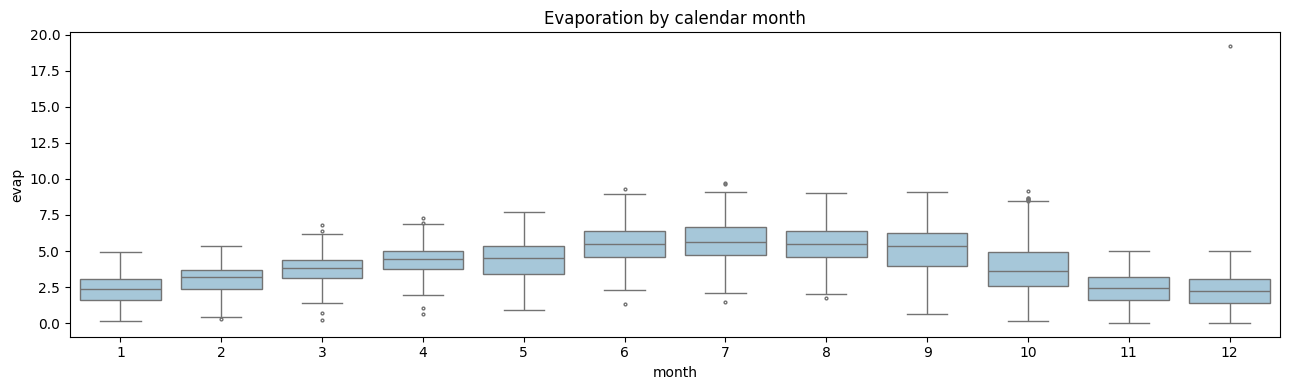

In [26]:
ts['month']=ts.index.month; ts['year']=ts.index.year
fig,ax=plt.subplots(1,figsize=(13,4))
sns.boxplot(data=ts,x='month',y='evap',ax=ax,color='#9ecae1',fliersize=2); ax.set_title('Evaporation by calendar month'); plt.tight_layout(); plt.savefig('fig_monthly_boxplot.png',dpi=130)


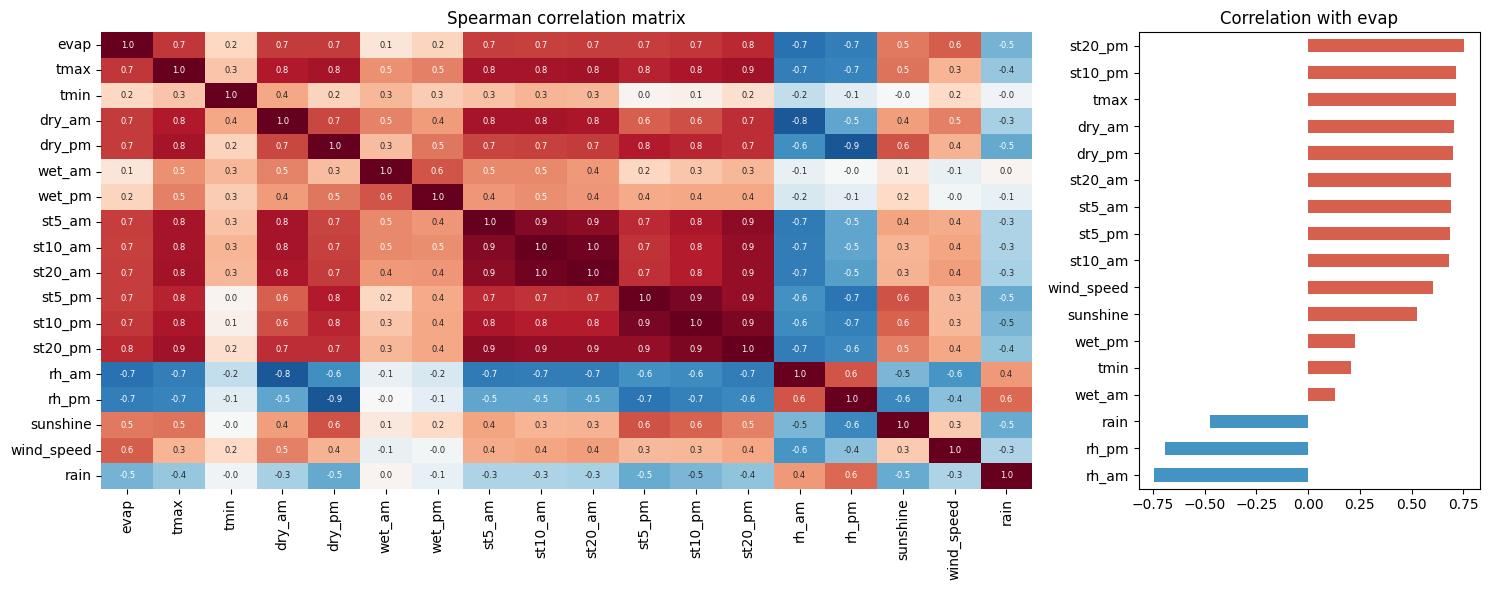

In [30]:
cor_cols=['evap','tmax','tmin','dry_am','dry_pm','wet_am','wet_pm','st5_am','st10_am','st20_am','st5_pm','st10_pm','st20_pm','rh_am','rh_pm','sunshine','wind_speed','rain']
sp=r[cor_cols].corr(method='spearman')
fig,ax=plt.subplots(1,2,figsize=(15,6),gridspec_kw={'width_ratios':[3,1.1]})
sns.heatmap(sp,cmap='RdBu_r',center=0,vmin=-1,vmax=1,ax=ax[0],annot=True,fmt='.1f',annot_kws={'size':6},cbar=False); ax[0].set_title('Spearman correlation matrix')
t=sp['evap'].drop('evap').sort_values(); t.plot.barh(ax=ax[1],color=np.where(t<0,'#4393c3','#d6604d')); ax[1].set_title('Correlation with evap')
plt.tight_layout(); plt.savefig('fig_corr.png',dpi=130); plt.show()

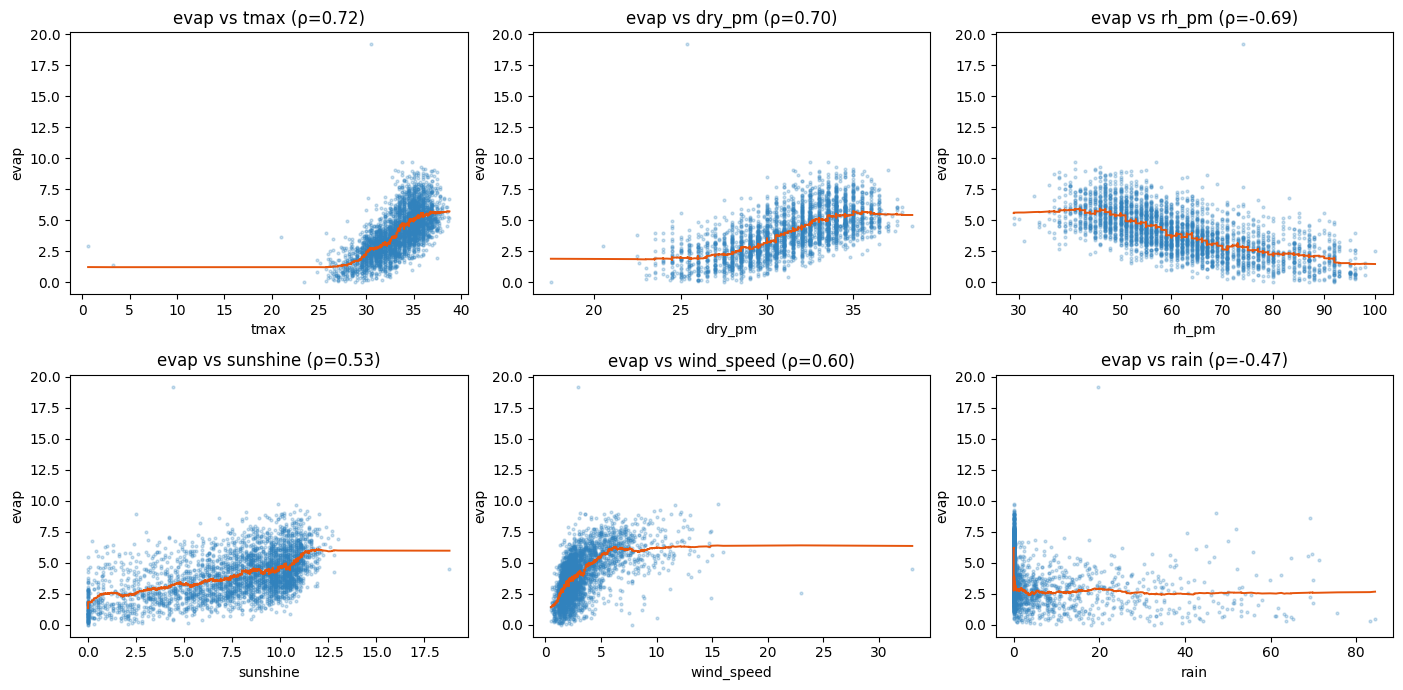

In [31]:
fig,axs=plt.subplots(2,3,figsize=(14,7)); axs=axs.ravel()
for a,c in zip(axs,['tmax','dry_pm','rh_pm','sunshine','wind_speed','rain']):
    a.scatter(r[c],r.evap,s=4,alpha=.25,color='#3182bd'); a.set_xlabel(c); a.set_ylabel('evap')
    s=r[[c,'evap']].dropna(); rho=stats.spearmanr(s[c],s.evap)[0]
    xs=s.sort_values(c); a.plot(xs[c],xs.evap.rolling(120,center=True,min_periods=40).mean(),color='#e6550d',lw=1.4); a.set_title(f'evap vs {c} (ρ={rho:.2f})')
plt.tight_layout(); plt.savefig('fig_scatter.png',dpi=130); plt.show()